# MTL Seismic Inference on SEG-Y (3D)

> Reference: *Iterative multitask learning and inference from seismic images* (Gao, 2024).

This notebook runs the **MTI-style inference path** used in this repository on a SEG-Y cube and produces:
- **RGT** (relative geological time, normalized to [0,1])
- **Fault attributes**: `fsem` (fault probability), `fdip`, `fstrike`
- Optional **DHR** output

## Project-aligned parameter expectations
- Training cubes in project scripts are typically `n1 x n2 x n3` (examples: `64^3`, `128^3`, `256^3`).
- Training batch parameters (`batch_train`, `batch_valid`) are defined in `src/main3_infer.py`/guides; inference here runs patch-by-patch with effective batch size 1.
- For large field volumes, tiled inference with overlap/blending is required to control GPU memory and reduce seams.

## Goal of this notebook
Run reproducible inference on `data/1_Original_Seismics.sgy` using the current checkpoint, and verify required outputs include **RGT** and **fault probability (`fsem`)**.

## Step 1 — Configure paths and inference parameters

This cell sets workspace paths, patch geometry, overlap, output toggles, and task switches.

Key inference controls:
- `PATCH`: 3D tile size processed by the model
- `OVERLAP`: shared voxels between adjacent tiles for blending
- `PREDICT_RGT`, `PREDICT_FAULT`: required outputs for this run

In [23]:
# Step 1: base imports
from pathlib import Path
import sys
import os
import numpy as np
import torch
import torch.nn as nn
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# Step 1: workspace and source paths
WORKSPACE = Path('/home/roderickperez/DataScienceProjects/multiTaskLearningSeismic')
SRC_DIR = WORKSPACE / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

# Step 1: IO paths
SGY_PATH = WORKSPACE / 'data/1_Original_Seismics.sgy'

# Use a stable checkpoint for MTI inference (last.ckpt may correspond to a noisier training state)
CKPT_PATH = WORKSPACE / 'result3_infer/epoch=56.ckpt'
if not CKPT_PATH.exists():
    CKPT_PATH = WORKSPACE / 'result3_infer/last.ckpt'

OUTPUT_DIR = WORKSPACE / 'test_output/prod_run_f3_sgy'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Step 1: tiling parameters for field-volume inference
PATCH = (128, 128, 128)   # (n1, n2, n3)
OVERLAP = 32               # overlap per axis; stride = PATCH - OVERLAP

# Step 1: normalization mode (reference notebook applies per-patch standardization)
NORMALIZE_PER_PATCH = True

# Step 1: task switches (required outputs: RGT + fault semantic)
PREDICT_RGT = True
PREDICT_DHR = True
PREDICT_FAULT = True
assert PREDICT_RGT and PREDICT_FAULT, 'This run requires RGT and fault outputs.'

# Step 1: output controls
SAVE_OUTPUTS = True   # Save full-volume .npy and project-format binary files
SAVE_PREVIEW = True

# Step 1: runtime device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
print('SGY exists:', SGY_PATH.exists(), SGY_PATH)
print('Checkpoint exists:', CKPT_PATH.exists(), CKPT_PATH)
print('Output dir:', OUTPUT_DIR)
print('Save outputs:', SAVE_OUTPUTS, '| Save preview:', SAVE_PREVIEW)
print('Per-patch normalization:', NORMALIZE_PER_PATCH)

Device: cuda
SGY exists: True /home/roderickperez/DataScienceProjects/multiTaskLearningSeismic/data/1_Original_Seismics.sgy
Checkpoint exists: True /home/roderickperez/DataScienceProjects/multiTaskLearningSeismic/result3_infer/epoch=56.ckpt
Output dir: /home/roderickperez/DataScienceProjects/multiTaskLearningSeismic/test_output/prod_run_f3_sgy
Save outputs: True | Save preview: True
Per-patch normalization: True


## Step 2 — Validate runtime dependencies

Checks required packages before heavy processing so failures appear early.

In [10]:
# Step 2: fail fast if required packages are missing
import importlib
for pkg in ["segyio", "torch", "lightning", "numpy"]:
    try:
        importlib.import_module(pkg)
        print(f"{pkg}: OK")
    except Exception as error:
        raise RuntimeError(
            f"Missing package {pkg}. Install with: uv sync\nDetails: {error}"
        )
print('Environment check complete.')

segyio: OK
torch: OK
lightning: OK
numpy: OK
Environment check complete.


## Step 3 — Define MTI inference model and tiling utilities

Defines the same output heads used in project training scripts:
- `rgt`
- `dhr`
- `fsem`, `fdip`, `fstrike`

Also defines overlap blending and padding utilities for full-volume tiled inference.

In [11]:
import segyio
from model3 import resu1, resu2, resu3, mtl_decoder, mtl_subdecoder, maxpool
from utility import write_array

class InferenceMTLNet(nn.Module):
    def __init__(self, predict_rgt=True, predict_dhr=True, predict_fault=True):
        super().__init__()
        self.predict_rgt = predict_rgt
        self.predict_dhr = predict_dhr
        self.predict_fault = predict_fault

        self.in_ch = 1
        self.l1, self.l2, self.l3 = 16, 32, 64

        self.encoder1 = resu1(self.in_ch, self.l1)
        self.encoder2 = resu2(self.l1, self.l2)
        self.encoder3 = resu3(self.l2, self.l3)

        if self.predict_rgt:
            self.decoder_rgt = mtl_decoder(self.l1, self.l2, self.l3, out_ch=1, out_activation='sigmoid')

        if self.predict_dhr:
            self.decoder_dhr = mtl_decoder(self.l1, self.l2, self.l3, out_ch=1, out_activation=None)

        if self.predict_fault:
            self.decoder_fault = mtl_decoder(self.l1, self.l2, self.l3, out_ch=self.l1, last_kernel_size=3)
            self.subdecoder_fault_semantic = mtl_subdecoder(in_ch=self.l1, out_ch=1, bn=False, mid_activation='relu', activation='sigmoid')
            self.subdecoder_fault_dip = mtl_subdecoder(in_ch=self.l1, out_ch=1, bn=True, mid_activation='relu', activation='sigmoid')
            self.subdecoder_fault_strike = mtl_subdecoder(in_ch=self.l1, out_ch=1, bn=True, mid_activation='relu', activation='sigmoid')

    def forward(self, x):
        out_encoder1 = self.encoder1(x)
        out_encoder2 = self.encoder2(maxpool(out_encoder1, 2))
        out_encoder3 = self.encoder3(maxpool(out_encoder2, 2))

        out = {}
        if self.predict_rgt:
            out['rgt'] = self.decoder_rgt(x, out_encoder1, out_encoder2, out_encoder3)
        if self.predict_dhr:
            out['dhr'] = self.decoder_dhr(x, out_encoder1, out_encoder2, out_encoder3)
        if self.predict_fault:
            out_fault = self.decoder_fault(x, out_encoder1, out_encoder2, out_encoder3)
            out_fault_semantic = self.subdecoder_fault_semantic(out_fault)
            out['fsem'] = out_fault_semantic
            out['fdip'] = self.subdecoder_fault_dip(out_fault) * out_fault_semantic
            out['fstrike'] = self.subdecoder_fault_strike(out_fault) * out_fault_semantic

        return out

def create_blend_mask(shape, overlap):
    def _w(size, ov):
        w = np.ones(size, dtype=np.float32)
        if ov > 0:
            t = np.linspace(0.0, np.pi / 2.0, ov, dtype=np.float32)
            left = np.sin(t) ** 2
            right = np.cos(t) ** 2
            w[:ov] = left
            w[-ov:] = right
        return w

    w1 = _w(shape[0], overlap)
    w2 = _w(shape[1], overlap)
    w3 = _w(shape[2], overlap)
    return np.einsum('i,j,k->ijk', w1, w2, w3).astype(np.float32)

def pad_for_tiling(vol, patch, overlap):
    stride = tuple(p - overlap for p in patch)
    p1 = (stride[0] - (vol.shape[0] - patch[0]) % stride[0]) % stride[0]
    p2 = (stride[1] - (vol.shape[1] - patch[1]) % stride[1]) % stride[1]
    p3 = (stride[2] - (vol.shape[2] - patch[2]) % stride[2]) % stride[2]
    padded = np.pad(vol, ((0, p1), (0, p2), (0, p3)), mode='constant', constant_values=0)
    return padded, stride

## Step 4 — Load SEG-Y cube and align dimensions

Project convention is `(n1, n2, n3)` = `(samples/depth, inline, xline)`.
This cell reads SEG-Y, reconstructs geometry if needed, transposes to project order, and computes global normalization stats.

In [18]:
# Step 4: read seismic cube from SEG-Y
import segyio
import numpy as np

with segyio.open(str(SGY_PATH), 'r', strict=False) as segy_file:
    try:
        cube = segyio.tools.cube(segy_file).astype(np.float32)
    except TypeError:
        print('Geometry not inferred by segyio; reconstructing cube from trace headers...')

# Step 4: fallback reconstruction when geometry metadata is incomplete
with segyio.open(str(SGY_PATH), 'r', strict=False, ignore_geometry=True) as segy_file:
    if 'cube' not in locals():
        traces = segyio.tools.collect(segy_file.trace[:]).astype(np.float32)  # (n_traces, n_samples)
        ilines = segy_file.attributes(segyio.TraceField.INLINE_3D)[:]
        xlines = segy_file.attributes(segyio.TraceField.CROSSLINE_3D)[:]

        unique_ilines = np.unique(ilines)
        unique_xlines = np.unique(xlines)
        i_idx = np.searchsorted(unique_ilines, ilines)
        x_idx = np.searchsorted(unique_xlines, xlines)

        cube = np.zeros((len(unique_ilines), len(unique_xlines), traces.shape[1]), dtype=np.float32)
        cube[i_idx, x_idx, :] = traces

print('Raw cube shape from segyio (iline, xline, samples):', cube.shape)

# Step 4: reorder to project convention (n1, n2, n3) = (samples, iline, xline)
seismic = np.transpose(cube, (2, 0, 1)).astype(np.float32)
print('Processing shape (n1, n2, n3):', seismic.shape)
print('Patch size (n1, n2, n3):', PATCH)

if any(s < p for s, p in zip(seismic.shape, PATCH)):
    raise ValueError(f'Volume shape {seismic.shape} must be >= patch {PATCH}')

# Step 4: global normalization stats used for all tiles
seismic_mean = float(seismic.mean())
seismic_std = float(seismic.std()) + 1e-8
print(f'Global mean={seismic_mean:.4f}, std={seismic_std:.4f}')

Geometry not inferred by segyio; reconstructing cube from trace headers...
Raw cube shape from segyio (iline, xline, samples): (651, 951, 463)
Processing shape (n1, n2, n3): (463, 651, 951)
Patch size (n1, n2, n3): (128, 128, 128)
Global mean=-2.0068, std=2442.3501


## Step 5 — Load checkpoint into inference model

Loads the selected `.ckpt` and reports key compatibility checks (`missing_keys`, `unexpected_keys`).

In [19]:
# Step 5: instantiate model with requested output heads
model = InferenceMTLNet(
    predict_rgt=PREDICT_RGT,
    predict_dhr=PREDICT_DHR,
    predict_fault=PREDICT_FAULT
)

# Step 5: load checkpoint weights
ckpt = torch.load(CKPT_PATH, map_location=device)
state_dict = ckpt['state_dict'] if isinstance(ckpt, dict) and 'state_dict' in ckpt else ckpt
missing_keys, unexpected_keys = model.load_state_dict(state_dict, strict=False)
model.to(device)
model.eval()

print('Model loaded from:', CKPT_PATH)
print('Missing keys:', len(missing_keys))
print('Unexpected keys:', len(unexpected_keys))
if missing_keys:
    print('First missing keys:', missing_keys[:10])
if unexpected_keys:
    print('First unexpected keys:', unexpected_keys[:10])

Model loaded from: /home/roderickperez/DataScienceProjects/multiTaskLearningSeismic/result3_infer/epoch=56.ckpt
Missing keys: 0
Unexpected keys: 0


## Step 6 — Run tiled full-volume inference

This is the main inference pass over all tiles, followed by weighted blending and crop-back to original cube size.

Important behavior:
- Uses global cube normalization (no per-tile renormalization)
- Applies overlap blending to reduce edge artifacts
- Normalizes `rgt` to [0,1] as done in project scripts

In [24]:
# Step 6: global normalization baseline
seis_norm = (seismic - seismic_mean) / seismic_std

# Step 6: tile planning
padded, stride = pad_for_tiling(seis_norm, PATCH, OVERLAP)
print('Padded shape:', padded.shape, 'Stride:', stride)
print('Effective inference batch per forward pass: 1 patch')

# Step 6: active output heads
active_outputs = []
if PREDICT_RGT:
    active_outputs.append('rgt')
if PREDICT_DHR:
    active_outputs.append('dhr')
if PREDICT_FAULT:
    active_outputs.extend(['fsem', 'fdip', 'fstrike'])

# Step 6: accumulation buffers for overlap blending
pred_acc = {k: np.zeros(padded.shape, dtype=np.float32) for k in active_outputs}
weight_acc = np.zeros(padded.shape, dtype=np.float32)
blend = create_blend_mask(PATCH, OVERLAP)

k1_range = range(0, padded.shape[0] - PATCH[0] + 1, stride[0])
k2_range = range(0, padded.shape[1] - PATCH[1] + 1, stride[1])
k3_range = range(0, padded.shape[2] - PATCH[2] + 1, stride[2])

total_tiles = len(k1_range) * len(k2_range) * len(k3_range)
print('Total tiles:', total_tiles)

# Step 6: tiled forward passes
with torch.no_grad():
    for k1 in tqdm(k1_range, desc='Tiles dim-1'):
        for k2 in k2_range:
            for k3 in k3_range:
                patch = padded[k1:k1+PATCH[0], k2:k2+PATCH[1], k3:k3+PATCH[2]]

                if NORMALIZE_PER_PATCH:
                    patch_in = (patch - patch.mean()) / (patch.std() + 1e-8)
                else:
                    patch_in = patch

                x = torch.from_numpy(patch_in).unsqueeze(0).unsqueeze(0).to(device=device, dtype=torch.float32)
                y = model(x)

                for key in active_outputs:
                    pred_patch = y[key].squeeze().detach().cpu().numpy().astype(np.float32)
                    pred_acc[key][k1:k1+PATCH[0], k2:k2+PATCH[1], k3:k3+PATCH[2]] += pred_patch * blend

                weight_acc[k1:k1+PATCH[0], k2:k2+PATCH[1], k3:k3+PATCH[2]] += blend

# Step 6: finalize blended predictions and crop to original cube
final_preds = {}
for key in active_outputs:
    merged = np.divide(pred_acc[key], weight_acc, out=np.zeros_like(pred_acc[key]), where=weight_acc > 0)
    final_preds[key] = merged[:seismic.shape[0], :seismic.shape[1], :seismic.shape[2]]

# Step 6: normalize RGT into [0,1] for interpretation consistency
if 'rgt' in final_preds:
    rgt = final_preds['rgt']
    rgt = rgt - np.min(rgt)
    rgt = rgt / (np.max(rgt) + 1e-8)
    final_preds['rgt'] = rgt

print('Inference complete.')
for key, arr in final_preds.items():
    print(key, arr.shape, arr.dtype, f'min={arr.min():.4f} max={arr.max():.4f}')

Padded shape: (512, 704, 992) Stride: (96, 96, 96)
Effective inference batch per forward pass: 1 patch
Total tiles: 350


Tiles dim-1:   0%|          | 0/5 [00:00<?, ?it/s]

Inference complete.
rgt (463, 651, 951) float32 min=0.0000 max=1.0000
dhr (463, 651, 951) float32 min=-19.7982 max=19.0240
fsem (463, 651, 951) float32 min=0.0000 max=0.9996
fdip (463, 651, 951) float32 min=0.0000 max=0.6921
fstrike (463, 651, 951) float32 min=0.0000 max=0.9983


## Step 7 — Validate required outputs (RGT + Fault)

This cell enforces that required outputs exist and prints compact statistics for quick QA.

In [21]:
required_keys = ['rgt', 'fsem']
missing = [k for k in required_keys if k not in final_preds]
if missing:
    raise RuntimeError(f'Missing required outputs: {missing}')

print('Required outputs are present:', required_keys)
for key in ['rgt', 'fsem', 'fdip', 'fstrike', 'dhr']:
    if key in final_preds:
        arr = final_preds[key]
        print(f"{key}: shape={arr.shape}, dtype={arr.dtype}, min={arr.min():.5f}, max={arr.max():.5f}, mean={arr.mean():.5f}")

Required outputs are present: ['rgt', 'fsem']
rgt: shape=(463, 651, 951), dtype=float32, min=0.00000, max=1.00000, mean=0.43730
fsem: shape=(463, 651, 951), dtype=float32, min=0.00000, max=0.99962, mean=0.18613
fdip: shape=(463, 651, 951), dtype=float32, min=0.00000, max=0.69185, mean=0.07645
fstrike: shape=(463, 651, 951), dtype=float32, min=0.00000, max=0.99832, mean=0.11219
dhr: shape=(463, 651, 951), dtype=float32, min=-19.79931, max=19.02501, mean=0.01140


## Step 8 — Save outputs and show 3-column results

Writes full-volume arrays and binary outputs, then displays a 3-column panel for each slice direction:
1. Seismic
2. Fault prediction
3. Seismic + fault overlay (50% opacity)

All subplot cells use uniform panel size, and fault probability is shown with a colorbar.

Saved files in: /home/roderickperez/DataScienceProjects/multiTaskLearningSeismic/test_output/prod_run_f3_sgy
Binary prefix: /home/roderickperez/DataScienceProjects/multiTaskLearningSeismic/test_output/prod_run_f3_sgy/f3_sgy


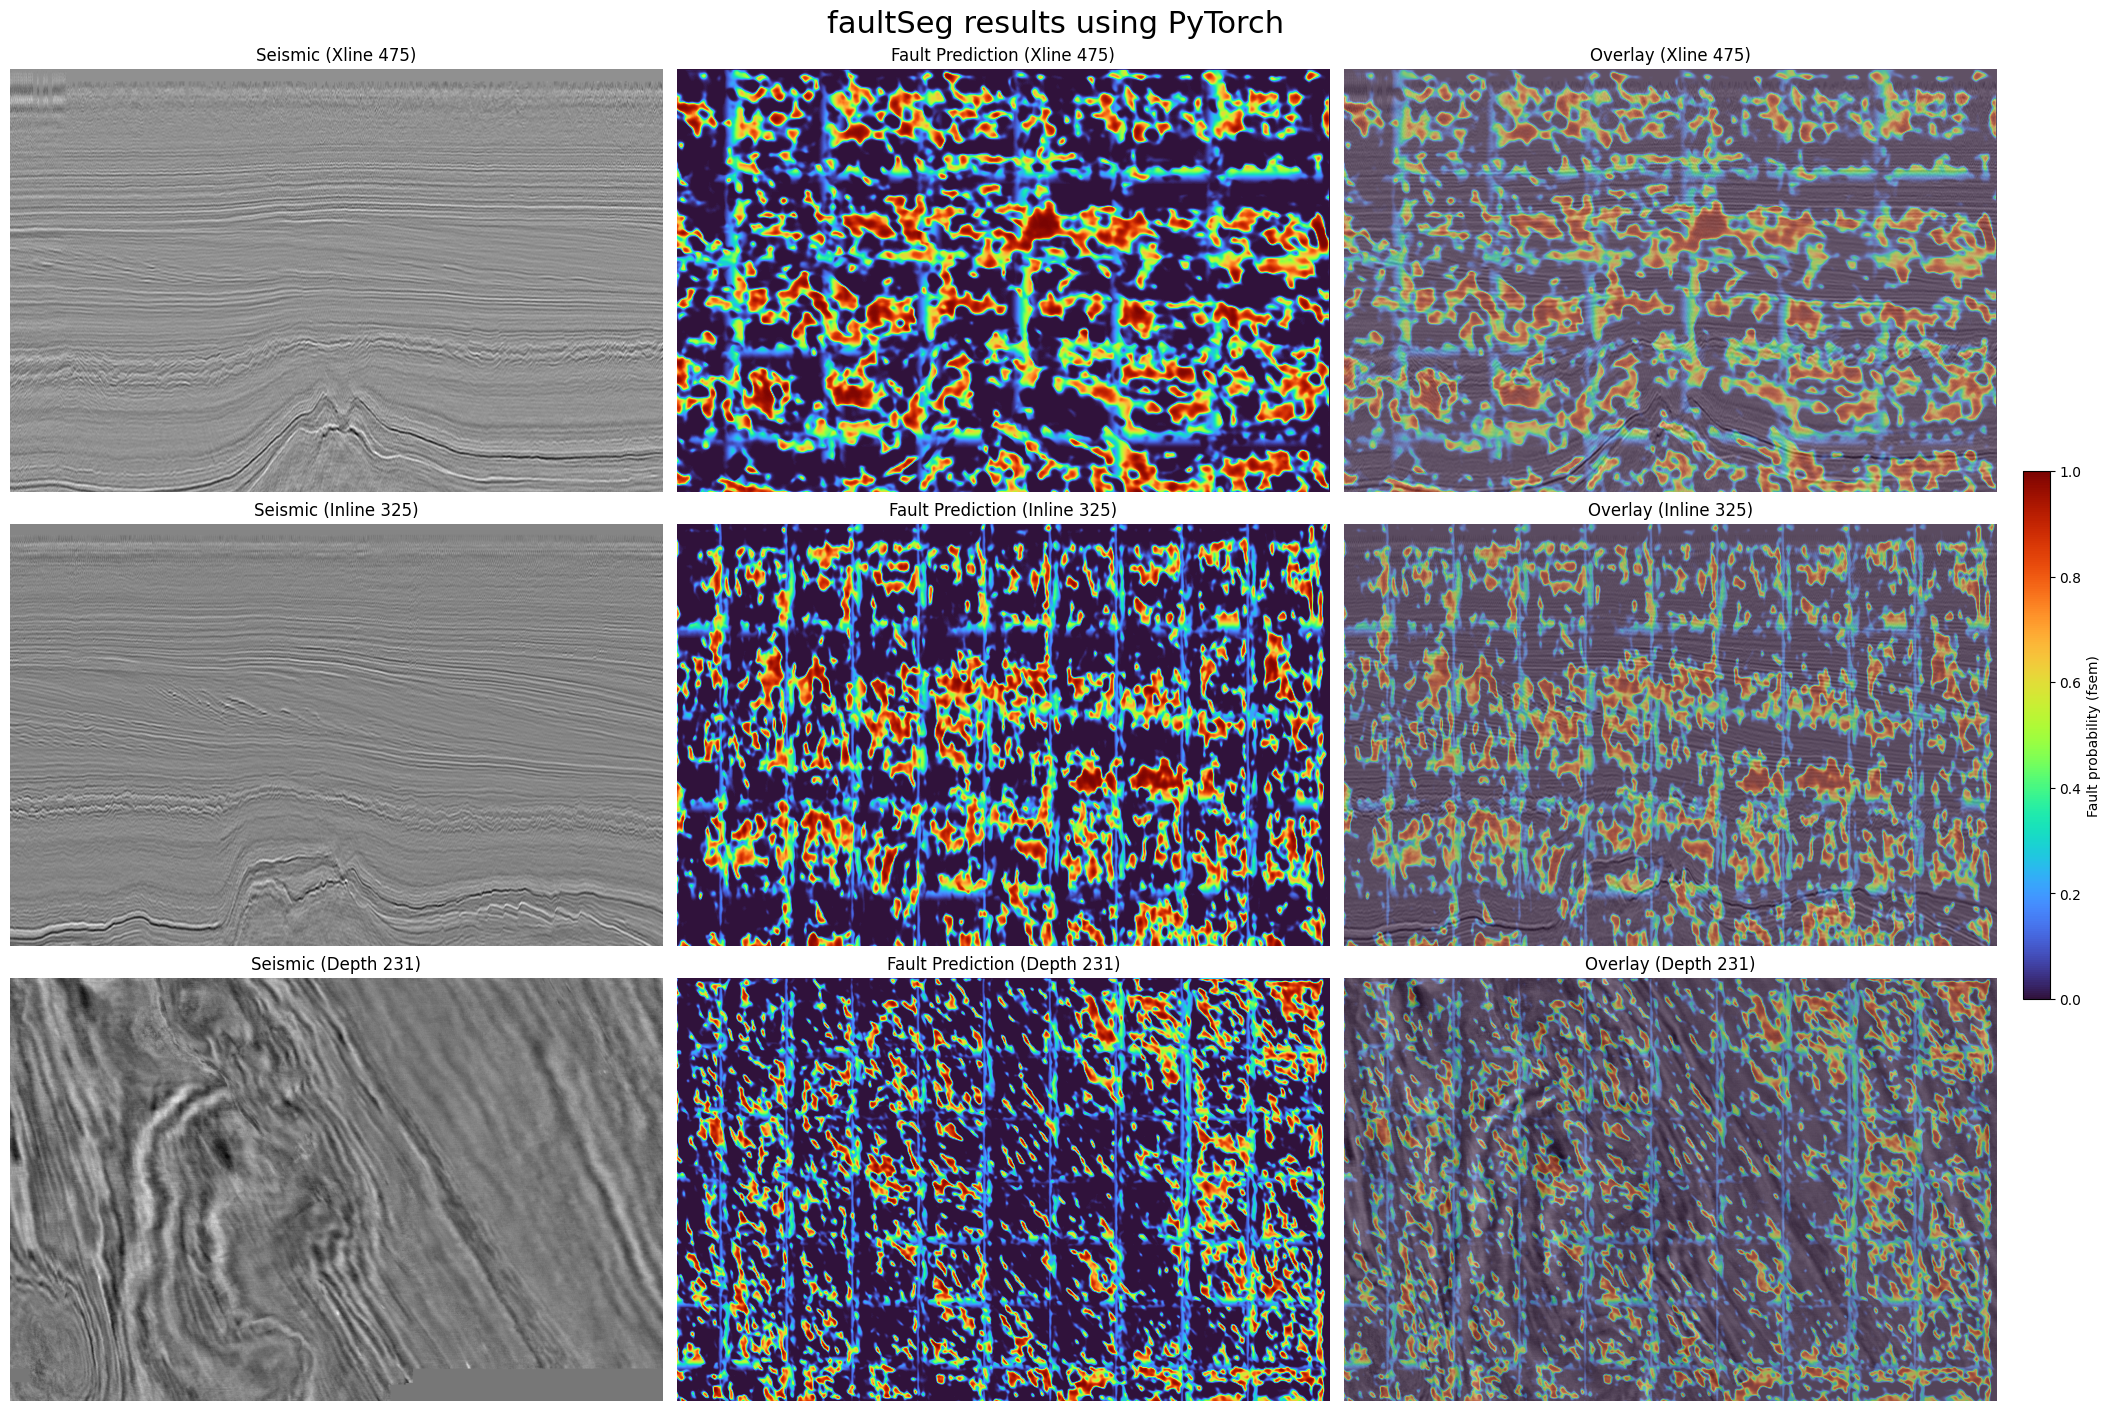

faultSeg results using PyTorch /home/roderickperez/DataScienceProjects/multiTaskLearningSeismic/test_output/prod_run_f3_sgy/faultSegResultsUsingPyTorch.png


In [ ]:
# Step 8: write outputs in project-compatible format
prefix = OUTPUT_DIR / 'f3_sgy'

if SAVE_OUTPUTS:
    for key, arr in final_preds.items():
        npy_path = OUTPUT_DIR / f'f3_sgy.{key}.npy'
        np.save(npy_path, arr.astype(np.float32))

        bin_suffix_map = {
            'rgt': '.rgt',
            'dhr': '.dhr',
            'fsem': '.fsem',
            'fdip': '.fdip',
            'fstrike': '.fstrike',
        }
        if key in bin_suffix_map:
            write_array(arr.astype(np.float32), str(prefix) + bin_suffix_map[key])

    print('Saved files in:', OUTPUT_DIR)
    print('Binary prefix:', prefix)
else:
    print('Skipping full-volume file writes (SAVE_OUTPUTS=False).')

# Step 8: 3-column visualization with equal panel sizes and overlay
if SAVE_PREVIEW:
    gx_orig_view = seismic
    fp_orig_view = final_preds['fsem']

    k1_depth = gx_orig_view.shape[0] // 2
    k2_inline = gx_orig_view.shape[1] // 2
    k3_xline = gx_orig_view.shape[2] // 2

    # Build right-rotated views
    gx_xline_view = np.rot90(np.transpose(gx_orig_view[:, :, k3_xline]), k=-1)
    fp_xline_view = np.rot90(np.transpose(fp_orig_view[:, :, k3_xline]), k=-1)

    gx_inline_view = np.rot90(np.transpose(gx_orig_view[:, k2_inline, :]), k=-1)
    fp_inline_view = np.rot90(np.transpose(fp_orig_view[:, k2_inline, :]), k=-1)

    gx_depth_view = np.rot90(np.transpose(gx_orig_view[k1_depth, :, :]), k=-1)
    fp_depth_view = np.rot90(np.transpose(fp_orig_view[k1_depth, :, :]), k=-1)

    views = [
        ('Xline', k3_xline, gx_xline_view, fp_xline_view),
        ('Inline', k2_inline, gx_inline_view, fp_inline_view),
        ('Depth', k1_depth, gx_depth_view, fp_depth_view),
    ]

    output_dir = OUTPUT_DIR
    os.makedirs(output_dir, exist_ok=True)

    fig, axes = plt.subplots(3, 3, figsize=(21, 21), constrained_layout=True)
    fig.suptitle('faultSeg results using PyTorch', fontsize=22)

    last_overlay_img = None
    for row, (name, idx, gx_view, fp_view) in enumerate(views):
        # Column 1: seismic
        axes[row, 0].set_title(f'Seismic ({name} {idx})')
        axes[row, 0].imshow(gx_view, cmap=plt.cm.gray, aspect='equal')
        axes[row, 0].set_box_aspect(1)
        axes[row, 0].axis('off')

        # Column 2: fault prediction
        axes[row, 1].set_title(f'Fault Prediction ({name} {idx})')
        axes[row, 1].imshow(fp_view, cmap='viridis', interpolation='bilinear', vmin=0.0, vmax=1.0, aspect='equal')
        axes[row, 1].set_box_aspect(1)
        axes[row, 1].axis('off')

        # Column 3: overlay (column 2 over column 1 at 50% opacity)
        axes[row, 2].set_title(f'Overlay 50% ({name} {idx})')
        axes[row, 2].imshow(gx_view, cmap=plt.cm.gray, aspect='equal')
        last_overlay_img = axes[row, 2].imshow(fp_view, cmap='viridis', interpolation='bilinear', vmin=0.0, vmax=1.0, alpha=0.5, aspect='equal')
        axes[row, 2].set_box_aspect(1)
        axes[row, 2].axis('off')

    # Shared colorbar for overlay/fault probability
    cbar = fig.colorbar(last_overlay_img, ax=axes[:, 2], fraction=0.025, pad=0.02)
    cbar.set_label('Fault probability (overlay colormap)', rotation=90)

    save_path = os.path.join(output_dir, 'faultSegResultsUsingPyTorch.png')
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f'faultSeg results using PyTorch {save_path}')
else:
    print('Skipping preview generation (SAVE_PREVIEW=False).')